## Importing Required Libraries
- We begin by importing essential Python libraries.<br>
  * `pandas`: For working with tables (DataFrames), cleaning and analyzing data.<br>
  * `os`: It lets us interact with folders and files on our computer<br>
  * `glob`: Helps find files using patterns (like all .csv files in a folder)<br>
  * `seaborn`: Makes it easy to create nice-looking charts.<br>
  * `matplotlib.pyplot`: A basic tool for making plots and graphs.<br>
  * `CategoricalDtype` from `pandas.api.types`: Used to handle data with fixed categories, like days of the week or survey options.

In [1]:
import pandas as pd
import os
import glob
import seaborn as sns
from matplotlib import pyplot as plt
from pandas.api.types import CategoricalDtype

## Setup Path and Load Datasets

In [2]:
path = os.getcwd()
csv_files = glob.glob(os.path.join(path, '*.csv'))
course = pd.read_csv(csv_files[0])
feedback = pd.read_csv(csv_files[1])
students = pd.read_csv(csv_files[2])

## Identifying Missing data, understanding features and cleaning Process

### For Course Activity Dataset

In [3]:
course.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659 entries, 0 to 658
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             659 non-null    object 
 1   Course_ID              659 non-null    object 
 2   Date                   659 non-null    object 
 3   Time_Spent_Minutes     659 non-null    int64  
 4   Completion_Percentage  659 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 25.9+ KB


In [4]:
course['Date'] = pd.to_datetime(course['Date'], format='%d/%m/%Y')
course.head()

,Student_ID,Course_ID,Date,Time_Spent_Minutes,Completion_Percentage
0,S001,PY202,2024-01-05,90,46.10
1,S001,DM101,2024-01-28,155,88.87
2,S001,UX303,2024-01-28,177,54.93
3,S002,PY202,2024-02-03,45,32.20
4,S002,UX303,2024-03-15,119,90.80


In [5]:
course.dtypes

Student_ID                       object
Course_ID                        object
Date                     datetime64[ns]
Time_Spent_Minutes                int64
Completion_Percentage           float64
dtype: object

### For Feedback Dataset

In [6]:
feedback.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Student_ID     80 non-null     object
 1   Course_ID      80 non-null     object
 2   Rating         80 non-null     int64 
 3   Feedback_Text  80 non-null     object
dtypes: int64(1), object(3)
memory usage: 2.6+ KB


In [7]:
feedback[['Student_ID', 'Course_ID']].duplicated().any()

np.False_

### For Students Dataset

In [8]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Student_ID      100 non-null    object
 1   Name            100 non-null    object
 2   Age             100 non-null    int64 
 3   Gender          100 non-null    object
 4   Location        100 non-null    object
 5   Enrolment_Date  100 non-null    object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB


In [9]:
students['Gender'].unique()

array(['Female', 'Other', 'Male'], dtype=object)

In [10]:
students[['Gender', 'Location']] = students[['Gender', 'Location']].astype('category')

In [11]:
students = students.rename(columns = {'Enrolment_Date': 'Enrollment_Date'})

In [12]:
students['Enrollment_Date'] = pd.to_datetime(students['Enrollment_Date'], format='%d/%m/%Y')

In [13]:
students[['Gender', 'Location', 'Enrollment_Date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Gender           100 non-null    category      
 1   Location         100 non-null    category      
 2   Enrollment_Date  100 non-null    datetime64[ns]
dtypes: category(2), datetime64[ns](1)
memory usage: 1.4 KB


In [14]:
students['Student_ID'].duplicated().any()

np.False_

## Exporting Cleaned Dataset

In [15]:
rep = 0
def final_dataset():
    global rep
    if (rep>0):
        print('Coming from Else')
    
    if (os.path.isdir('./cleaned_datasets')):
        os.chdir('./cleaned_datasets')
        print('Directory changed!')
        course.to_csv('course_final.csv')
        print('Course csv created!')
        feedback.to_csv('feedback_final.csv')
        print('Feedback csv created!')
        students.to_csv('students_final.csv')
        print('Students csv created!')
        os.chdir('../')
    else:
        os.mkdir('./cleaned_datasets')
        print('Dir Created in Else')
        rep = 1
        final_dataset()

final_dataset()

Directory changed!
Course csv created!
Feedback csv created!
Students csv created!


## Exploratory Data Analysis

### **Question 1**: What is the overall average completion rate across courses?

In [16]:
course_time = course.groupby('Course_ID')['Time_Spent_Minutes'].mean()
course_time.sort_values(ascending=False)

Course_ID
DM101    102.427673
UX303     99.816568
WD404     96.419162
PY202     93.902439
Name: Time_Spent_Minutes, dtype: float64

### **Question 2**: Which course has the highest and lowest average engagement time?

In [17]:
print(f'Course ID - {course_time.idxmax()} have highest average engagement time: {course_time.max().round(2)}')
print(f'Course ID - {course_time.idxmin()} have lowest average engagement time: {course_time.min().round(2)}')

Course ID - DM101 have highest average engagement time: 102.43
Course ID - PY202 have lowest average engagement time: 93.9


### **Question 3**: How does engagement differ by age group or location?

In [18]:
merged_stu_course = course.merge(students, on='Student_ID')
merged_stu_course.head()

,Student_ID,Course_ID,Date,Time_Spent_Minutes,Completion_Percentage,Name,Age,Gender,Location,Enrollment_Date
0,S001,PY202,2024-01-05,90,46.10,Student_1,24,Female,Kolkata,2023-11-24
1,S001,DM101,2024-01-28,155,88.87,Student_1,24,Female,Kolkata,2023-11-24
2,S001,UX303,2024-01-28,177,54.93,Student_1,24,Female,Kolkata,2023-11-24
3,S002,PY202,2024-02-03,45,32.20,Student_2,32,Other,Chennai,2023-02-27
4,S002,UX303,2024-03-15,119,90.80,Student_2,32,Other,Chennai,2023-02-27


In [19]:
merged_stu_course.groupby(['Course_ID', 'Location'], observed=False)['Time_Spent_Minutes'].mean() \
    .reset_index() \
    .sort_values(by=['Time_Spent_Minutes'], ascending=False)

,Course_ID,Location,Time_Spent_Minutes
3,DM101,Kolkata,117.250000
19,WD404,Mumbai,115.600000
2,DM101,Delhi,112.583333
13,UX303,Kolkata,107.375000
7,PY202,Delhi,105.525000
0,DM101,Bangalore,104.789474
18,WD404,Kolkata,100.111111
10,UX303,Bangalore,100.097561
17,WD404,Delhi,99.260000
14,UX303,Mumbai,99.000000


In [20]:
merged_stu_course.groupby('Location', observed=False)['Time_Spent_Minutes'].sum().sort_values(ascending=False)

Location
Delhi        18078
Bangalore    17150
Chennai      15370
Kolkata       8142
Mumbai        5917
Name: Time_Spent_Minutes, dtype: int64

In [21]:
merged_stu_course['Age_Group'] = pd.cut(
    merged_stu_course['Age'],
    bins = [18, 23, 28, 33, 38],
    labels = ['18-23', '24-28', '29-33', '33-38']
)

In [22]:
merged_stu_course.groupby(['Course_ID', 'Age_Group'], observed=False)['Time_Spent_Minutes'].mean() \
    .reset_index() \
    .sort_values(by=['Age_Group'], ascending=False)

,Course_ID,Age_Group,Time_Spent_Minutes
3,DM101,33-38,110.200000
7,PY202,33-38,92.800000
11,UX303,33-38,70.000000
15,WD404,33-38,71.125000
2,DM101,29-33,92.978261
6,PY202,29-33,94.938776
10,UX303,29-33,99.880000
14,WD404,29-33,92.375000
1,DM101,24-28,112.000000
5,PY202,24-28,89.700000


### **Question 4**: What is the average feedback rating per course?

In [23]:
feedback.groupby('Course_ID')['Rating'].mean().sort_values(ascending=False)

Course_ID
PY202    3.277778
UX303    2.923077
DM101    2.900000
WD404    2.789474
Name: Rating, dtype: float64

### **Question 5**: Is there a correlation between completion rate and feedback rating?

In [24]:
merged_cou_feedback = feedback.merge(course, on=['Course_ID', 'Student_ID'])
merged_cou_feedback.head()

,Student_ID,Course_ID,Rating,Feedback_Text,Date,Time_Spent_Minutes,Completion_Percentage
0,S057,UX303,2,Too fast-paced,2024-01-09,98,31.70
1,S057,UX303,2,Too fast-paced,2024-03-10,96,83.22
2,S063,PY202,2,Loved the examples,2024-02-25,138,91.96
3,S063,PY202,2,Loved the examples,2024-01-21,92,94.13
4,S063,PY202,2,Loved the examples,2024-02-14,142,90.54


In [25]:
correlation = merged_cou_feedback['Rating'].corr(merged_cou_feedback['Completion_Percentage'])

print(f"Correlation between Completion rate and Feedback rating: {correlation:.3f}")

Correlation between Completion rate and Feedback rating: -0.052


In [26]:
merged_cou_feedback[['Rating', 'Completion_Percentage']].corr()

,Rating,Completion_Percentage
Rating,1.000000,-0.051708
Completion_Percentage,-0.051708,1.000000


### **Question 6**: Identify top 3 student segments based on engagement and satisfaction.

In [27]:
merged_all = students.merge(merged_cou_feedback, on='Student_ID')
merged_all.head()

,Student_ID,Name,Age,Gender,Location,Enrollment_Date,Course_ID,Rating,Feedback_Text,Date,Time_Spent_Minutes,Completion_Percentage
0,S002,Student_2,32,Other,Chennai,2023-02-27,PY202,3,Well structured,2024-02-03,45,32.20
1,S002,Student_2,32,Other,Chennai,2023-02-27,PY202,3,Well structured,2024-03-06,136,18.18
2,S005,Student_5,24,Other,Delhi,2023-05-06,DM101,4,Loved the examples,2024-01-30,27,91.49
3,S006,Student_6,28,Other,Delhi,2023-04-25,DM101,1,Loved the examples,2024-03-27,177,98.57
4,S006,Student_6,28,Other,Delhi,2023-04-25,DM101,1,Loved the examples,2024-01-08,113,75.54


In [28]:
merged_all['Age_Group'] = pd.cut(merged_all['Age'], bins = [18, 23, 28, 33, 38],
                                 labels = ['18-23', '24-28', '29-33', '33-38'])

In [29]:
segment_stats = merged_all.groupby(['Age_Group', 'Location'], observed=False).agg({
    'Time_Spent_Minutes': 'mean',
    'Rating': 'mean'
}).reset_index()

In [30]:
segment_stats['Score'] = (
    segment_stats['Time_Spent_Minutes'] * 0.5 + segment_stats['Rating'] * 0.5
)

In [31]:
top_segments = segment_stats.sort_values(by='Score', ascending=False).head(3)
top_segments

,Age_Group,Location,Time_Spent_Minutes,Rating,Score
9,24-28,Mumbai,148.000000,4.500000,76.250000
0,18-23,Bangalore,132.000000,2.333333,67.166667
5,24-28,Bangalore,123.222222,3.222222,63.222222


## Visualizations

### Show Engagement patterms by course and demographic

#### Total Time Spent on Specific Course by Male, Female and Other

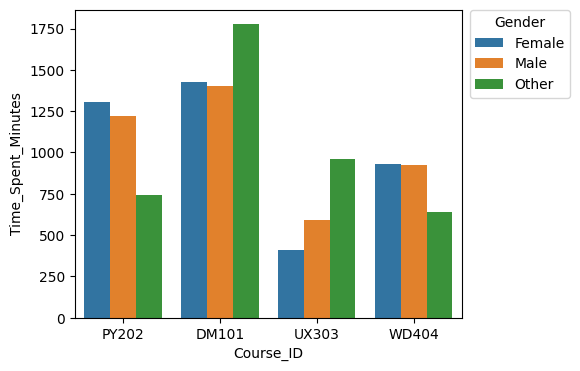

In [32]:
plt.figure(figsize=(5, 4))
sns.barplot(data=merged_all, x='Course_ID', y='Time_Spent_Minutes', hue='Gender', estimator='sum', errorbar=None)
plt.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#### Total Time Spent on Specific Course by different Age Groups

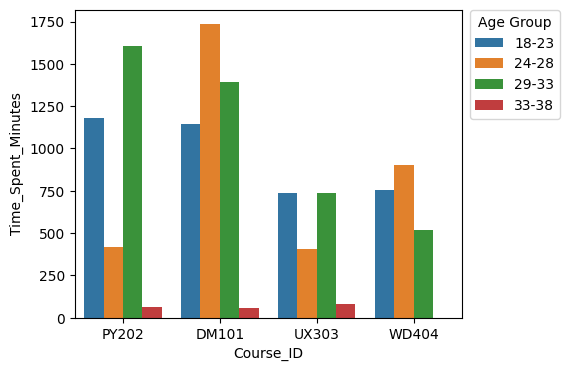

In [33]:
plt.figure(figsize=(5, 4))
sns.barplot(data=merged_all, x='Course_ID', y='Time_Spent_Minutes', hue='Age_Group', estimator='sum', errorbar=None)
plt.legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#### Total Time Spent on Specific Course from different Locations

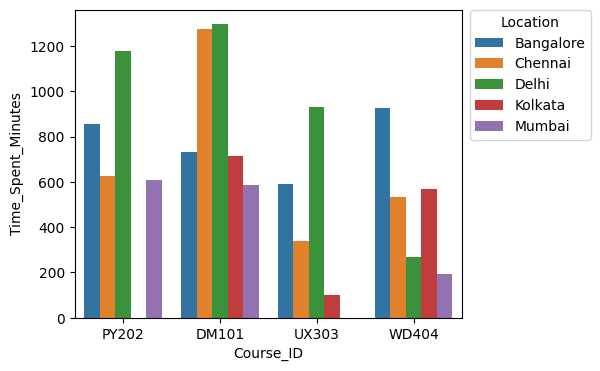

In [34]:
plt.figure(figsize=(5, 4))
sns.barplot(data=merged_all, x='Course_ID', y='Time_Spent_Minutes', hue='Location', estimator='sum', errorbar=None)
plt.legend(title='Location', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#### Total Time Spent for Specific Course on different Months

In [35]:
merged_all['Month'] = merged_all['Date'].dt.month_name()
merged_all['Month'].unique()

array(['February', 'March', 'January'], dtype=object)

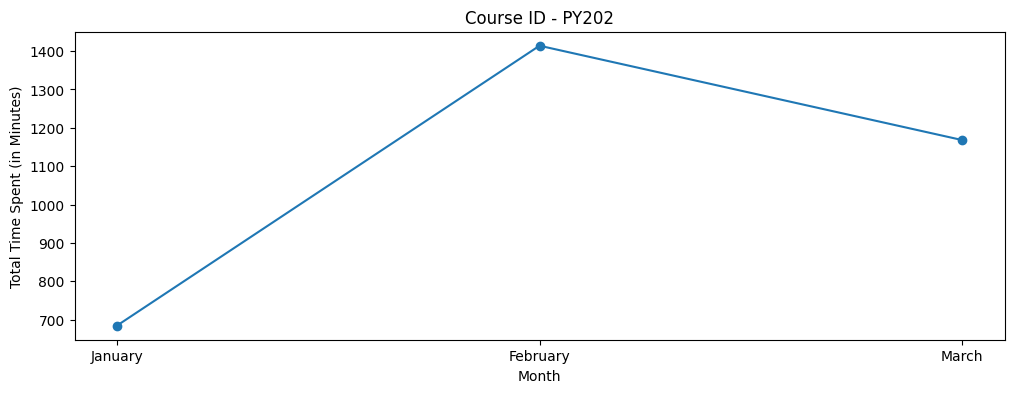

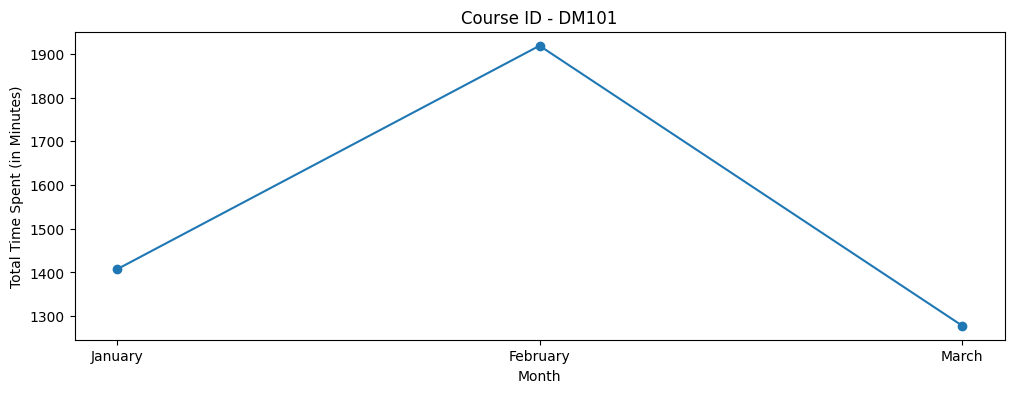

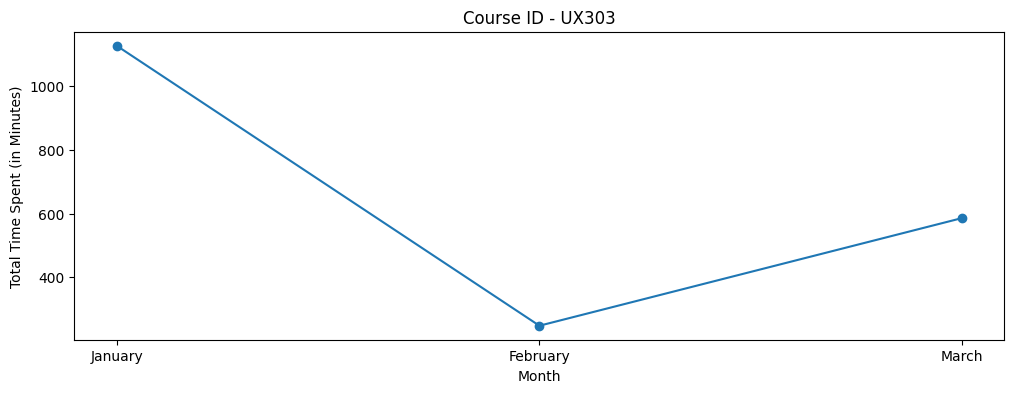

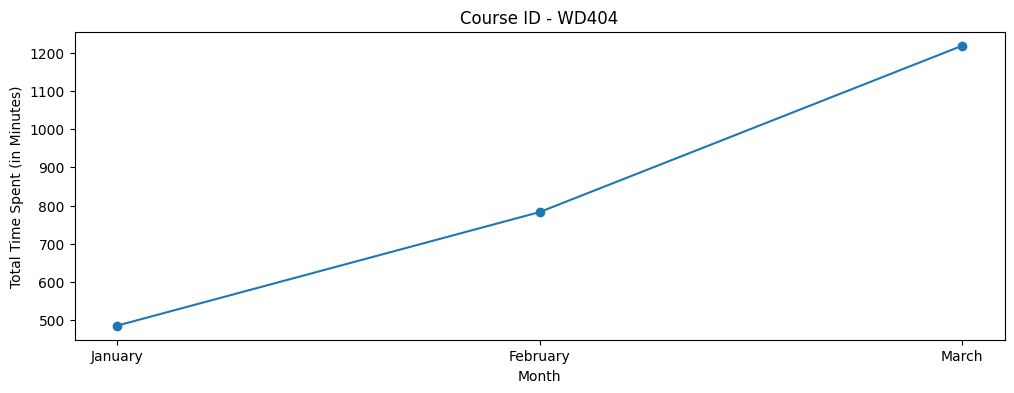

In [36]:
month_order = ['January', 'February', 'March']
month_cat = CategoricalDtype(categories=month_order, ordered=True)

merged_all['Month'] = merged_all['Month'].astype(month_cat)

for i in merged_all['Course_ID'].unique():
    plt.figure(figsize=(12, 4))
    data = merged_all[merged_all['Course_ID'] == i]
    data_agg = data.groupby('Month', as_index=False, observed=False)['Time_Spent_Minutes'].sum()
    plt.plot(data_agg['Month'], data_agg['Time_Spent_Minutes'], marker='o', linestyle='-')
    plt.title(f'Course ID - {i}')
    plt.xlabel('Month')
    plt.ylabel('Total Time Spent (in Minutes)')

#### Average Time Spent on Specific Course from different locations

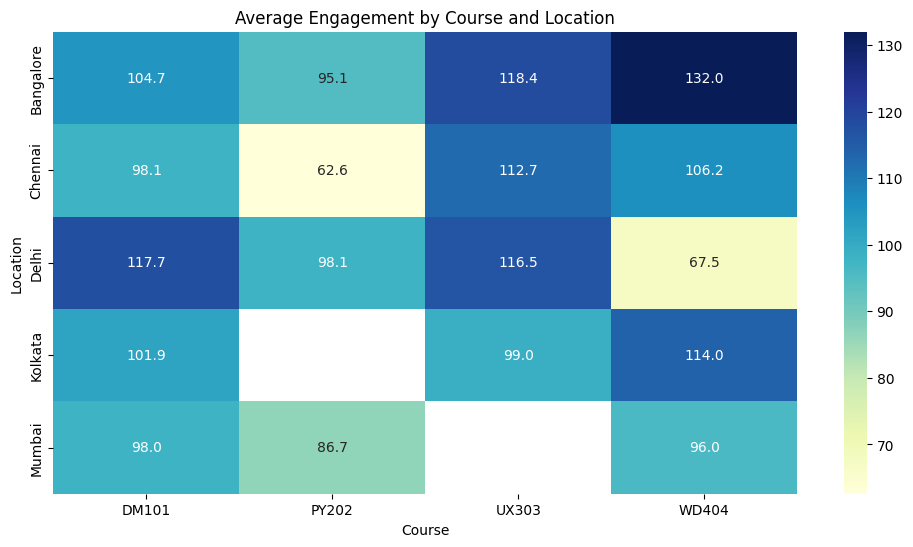

In [37]:
pivot = merged_all.pivot_table(index='Location', columns='Course_ID', values='Time_Spent_Minutes', aggfunc='mean', observed=False)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Average Engagement by Course and Location')
plt.ylabel('Location')
plt.xlabel('Course')
plt.show()

## Key Insights

1. Course `DM101` has the highest average engaging course (in Time) among all.
2. Course `PY202` has the highest average rating of 3.277778 among all.
3. **Most top 3 viewership** is coming from `Delhi with 3674 minutes`, `Bangalore with 3105 minutes`, and `Chennai with 2770 minutes`.
4. `Female` users spent the most time watching in **January**, `Male` users in **February*, and `Other` users in **March**.
5. `The age group 24–28` recorded the highest overall viewing and rating activity.

## Business Recommendations

1. Promote high-rated and viewed courses (`PY202` and `DM101`) in future batches and marketing campaigns to increase enrollments and satisfaction.
2. Launch city-specific engagement campaigns in Delhi, Bangalore, and Chennai to leverage high existing interest and drive further engagement.
3. Schedule gender-focused promotions based on their peak months of activity—target females in January, males in February, and others in March to maximize engagement timing.